# ADS-509 Assignment 1.1
## Collecting Text Data via API and Web Scraping

**Student Version**  

In this assignment you will:
- Collect story metadata via an API (Hacker News).
- Scrape discussion comments from HTML using BeautifulSoup.
- Merge into one tidy dataset (one row per comment with story metadata).
- Save results and run some quick checks/EDA.

Although the discussion posts are available via the HackerNews API, this mirrors real-world pipelines where structured APIs don’t expose the exact text you need, so you complement them with carefully designed scrapers.

## General Assignment Instructions

These instructions are included in every assignment, to remind you of the coding standards for the class. Feel free to delete this cell after reading it.

Work through this notebook as if it were a worksheet, completing the code sections marked with **TODO** in the cells provided. Similarly, written questions will be marked by a "Q:" and will have a corresponding "A:" spot for you to fill in with your answers. **Make sure to answer every question marked with a Q: for full credit**.

Your code should be relatively easy-to-read, sensibly commented, and clean. Writing code is a messy process, so please be sure to edit your final submission. Remove any cells that are not needed or parts of cells that contain unnecessary code. Remove inessential import statements and make sure that all such statements are moved into the designated cell.

A .pdf of this notebook, with your completed code and written answers, is what you should submit in Canvas for full credit. **DO NOT SUBMIT A NEW NOTEBOOK FILE OR A RAW .PY FILE**. Submitting in a different format makes it difficult to grade your work, and students who have done this in the past inevitably miss some of the required work or written questions.

## Imports and Definitions

First we import our libraries, set up our folder structure, and define some useful functions and variables.

**TODO**
- update the directory names with whatever path you would like to use to store your data
- define a function that will cause your code to "sleep" for a random interval between 1 and 2 seconds

In [1]:
import os, json, time, random
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# Polite scraping: set a clear user agent and throttle requests a bit
HEADERS = {"User-Agent": "MADS-LLM-2025-Student/1.0 (+https://example.edu)"}
BASE = "https://hacker-news.firebaseio.com/v0"

def sleep_politely(sleep_range=(1.0,2.0)):
    
    time.sleep(random.uniform(*sleep_range)) #random sleep function 

In [3]:
# define your folder structure

DATA_DIR = 'data/module1'
RAW_API_DIR = os.path.join(DATA_DIR, 'raw_api')
RAW_HTML_DIR = os.path.join(DATA_DIR, 'raw_html')
for d in [DATA_DIR, RAW_API_DIR, RAW_HTML_DIR]:
    os.makedirs(d, exist_ok=True)

## API Data Collection

Here we will use the **requests** library to interact with the HackerNews API. Our ultimate goal is to create a dataset with metadata and discussion posts for 50 of the top stories on this website, so first we will use the API to get the top story IDs.

**TODO**:
- Read through the HackerNews API documentation (https://github.com/HackerNews/API) and use the requests library to pull the IDs for all top news stories. *Be sure to use the headers and timeout arguments*.

**Q:** What do the headers and timeout arguments in the requests library do?

**A:** The headers argument sends information about who is making the request, such as the User-Agent. The timeout argument limits how long the program will wait for a response before stopping the request.

In [5]:
# Get a big list of top story IDs
r = requests.get(f"{BASE}/topstories.json", headers=HEADERS, timeout=10)
r.raise_for_status()
top_ids = r.json()
print('Total top story ids returned:', len(top_ids))

# For a faster assignment, we’ll just use the first 50 stories
CANDIDATE_N = 50
candidate_ids = top_ids[:CANDIDATE_N]
len(candidate_ids), candidate_ids[:5] # Print 5 of the IDs as a self-check

Total top story ids returned: 500


(50, [49615537, 49617581, 49617255, 49611251, 49605915])

Next we need to use our list of article IDs to pull and organize the metadata that we want to include in our final dataset.

**TODO**:
- Use the HackerNews API documentation to pull the metadata for each of the stories in your candidate_ids list.
- Filter your stories for those with discussion threads. Hint: look for the "descendants" column.
- Format your stories with their associated metadata into a pandas dataframe. Hint: check out the Pandas `json_normalize()` function

In [6]:
def fetch_item(item_id):

    # cache to disk so re-runs are fast and reproducible

    fp = os.path.join(RAW_API_DIR, f"item_{item_id}.json")

    if os.path.exists(fp):

        with open(fp, 'r', encoding='utf-8') as f:

            return json.load(f)

    r = requests.get(f"{BASE}/item/{item_id}.json", headers=HEADERS, timeout=10)

    r.raise_for_status()

    data = r.json()

    with open(fp, 'w', encoding='utf-8') as f:

        json.dump(data, f)

    sleep_politely()

    return data


items = []

for idx, i in enumerate(candidate_ids):

    if idx%5==0:

        print(f"{idx}/{len(candidate_ids)}")

    items.append(fetch_item(i))


stories = [item for item in items if item.get("type") == "story" and item.get("descendants", 0) > 0]


# TODO: Format your data into a pandas dataframe with one row per story, keeping only the metadata columns listed in keep_cols

keep_cols = ["id", "title", "by", "time", "url", "score", "descendants"]

stories_df = pd.DataFrame(stories)[keep_cols]

print('Stories w/ discussion:', len(stories_df))

stories_df.head()

0/50
5/50
10/50
15/50
20/50
25/50
30/50
35/50
40/50
45/50
Stories w/ discussion: 48


,id,title,by,time,url,score,descendants
0,49615537,Muse – Meta’s personal AI agent,yks,1788895500,https://ai.meta.com/muse/,277,267
1,49617581,Large language models develop novel social bia...,paimapi,1788904058,https://openreview.net/challenge?redirect=%2Ff...,86,45
2,49617255,How to build a printer,cat-whisperer,1788902531,https://nishantjosh.dev/blogs/how-to-build-a-f...,118,26
3,49611251,AlphaGenome Atlas: a high-resolution map of hu...,utiiiD,1788879345,https://blog.google/innovation-and-ai/models-a...,487,115
4,49605915,Navier-Stokes – Tristan Buckmaster [pdf],procedurecall,1788846148,https://cims.nyu.edu/~tristanb/statement.pdf,1219,533


## Webscraping

Next, we will use our list of story IDs to scrape the discussion threads from HackerNews using the BeautifulSoup library.

**TODO**:
- Use the requests library to pull the html for each story's comment page on Hacker News (https://news.ycombinator.com/). Hint: you'll need to go to the website to see how to format your url properly.
- Use the BeautifulSoup library to extract the user, comment id, time span, and comment text from each story's HTML. Hint: use the html inspector (ctrl+shift+i) to identify relevant html tags in your browser.
- Format the comment threads into a pandas dataframe with the story id and one row per comment.

**Q**: Find the HackerNews robots.txt. What does it say about scraping, and are we acting within its stated policy?

**A**: The Hacker News robots.txt allows scraping of public pages but specifies a 30-second crawl delay and restricts certain pages such as login, voting, and reply pages.

In [7]:
def get_discussion_html(story_id):
    fp = os.path.join(RAW_HTML_DIR, f"hn_{story_id}.html")
    if os.path.exists(fp):
        with open(fp, 'r', encoding='utf-8') as f:
            return f.read()

    url = f"https://news.ycombinator.com/item?id={story_id}"
    r = requests.get(url, headers=HEADERS, timeout=10)
    r.raise_for_status()

    html = r.text

    with open(fp, 'w', encoding='utf-8') as f:
        f.write(html)

    sleep_politely(sleep_range=(30.0,31.0)) # Adjust sleep according to robots.txt
    return html


# Simple HTML -> comments parser
def parse_comments_from_html(html, story_id):
    soup = BeautifulSoup(html, 'html.parser')
    rows = []

    # Extract comment_id, user, time span, and comment text from each comment in the html
    for tr in soup.select('tr.comtr'):
        comment_id = tr.get('id')

        user_tag = tr.select_one('.hnuser')
        user = user_tag.get_text(strip=True) if user_tag else None

        time_tag = tr.select_one('.age')
        time_text = time_tag.get_text(strip=True) if time_tag else None

        comment_tag = tr.select_one('.commtext')
        comment_text = comment_tag.get_text(" ", strip=True) if comment_tag else None

        if comment_text:
            rows.append({
                'story_id': story_id,
                'comment_id': comment_id,
                'user': user,
                'time_text': time_text,
                'comment_text': comment_text,
            })

    return rows


all_comments = []

for idx, sid in enumerate(stories_df['id'].tolist()):
    if idx%5==0:
        print(f"{idx}/{len(stories_df['id'])}")

    html = get_discussion_html(sid)
    all_comments.extend(parse_comments_from_html(html, sid))


comments_df = pd.DataFrame(all_comments)

print('Total comments scraped:', len(comments_df))

comments_df.head()

0/48
5/48
10/48
15/48
20/48
25/48
30/48
35/48
40/48
45/48
Total comments scraped: 5155


,story_id,comment_id,user,time_text,comment_text
0,49615537,49619077,abixb,49 minutes ago,I think Meta's strategy is to capture the 'nor...
1,49615537,49619121,ajkjk,43 minutes ago,"I think you're right, but I'd add that... if t..."
2,49615537,49619171,abixb,38 minutes ago,> you should really question your worldview a ...
3,49615537,49619253,wredcoll,28 minutes ago,"You don't have to ""be like"" anyone but yoursel..."
4,49615537,49619299,ajkjk,21 minutes ago,well probably even your friends know a lot mor...


## Combine Datasets

Now we have two dataframes that need to be combined into a single dataset. Luckily, these dataframes have a shared key which will make it relatively simple to combine them, but that is often not the case, so you need to be creative about which pieces of data you could use to merge data from multiple sources.

**TODO**
- Combine your `stories_df` and `comments_df` dataframes using the shared key so that the resulting dataset has one line per comment.
- As a final cleaning step, convert the timestamp column from Unix epoch format to a pandas datetime format

**Q**: If we didn't have a shared key for the two dataframes in this scenario, what could you use instead to join them?

**A**: If there were no shared ID, we could try to join the datasets using other matching information, such as the story URL or title. These fields may not be as reliable as a unique ID, so we would need to check for duplicates or differences between the datasets.

In [8]:
# TODO: merge your two dataframes
merged_df = comments_df.merge(
    stories_df,
    left_on='story_id',
    right_on='id',
    how='left')

# TODO: convert the timestamp to datetime format
merged_df['story_time'] = pd.to_datetime(merged_df['time'], unit='s')

assert merged_df['comment_text'].notna().all()
print('Rows in merged dataset:', len(merged_df))
merged_df.sample(3)

Rows in merged dataset: 5155


,story_id,comment_id,user,time_text,comment_text,id,title,by,time,url,score,descendants,story_time
331,49617255,49618730,stavros,1 hour ago,I've been seeing the Xteink a lot lately. Shou...,49617255,How to build a printer,cat-whisperer,1788902531,https://nishantjosh.dev/blogs/how-to-build-a-f...,118,26,2026-09-08 21:22:11
2435,49610631,49613136,hungryhobbit,8 hours ago,Output styles are just more context (like CLAU...,49610631,I-have-ADHD: A skill to stop coding agents fro...,domhudson,1788876806,https://github.com/ayghri/i-have-adhd,308,243,2026-09-08 14:13:26
1617,49613262,49614061,peri-cl,7 hours ago,I suspect this controversy will blow the case ...,49613262,On the Navier–Stokes Millennium Prize Problem,tedsanders,1788887601,https://openai.com/index/navier-stokes-solution/,1092,951,2026-09-08 17:13:21


## Save your dataset for future use

We will be using this dataset in future assignments, so use this code to save it to file.

In [9]:
out_csv = os.path.join(DATA_DIR, 'hn_comments_with_storymeta.csv')
merged_df.to_csv(out_csv, index=False)
out_csv

'data/module1/hn_comments_with_storymeta.csv'

## Validation

This section is used for grading. Please run these cells before submission, but do not change any of the code.

In [10]:
comments_per_story = (
    merged_df.groupby(['story_id','title']).size()
    .rename('n_comments').reset_index()
)
comments_per_story.sort_values('n_comments', ascending=False).head(10)

,story_id,title,n_comments
33,49613262,On the Navier–Stokes Millennium Prize Problem,955
13,49605767,Mistral raises €3B,565
14,49605915,Navier-Stokes – Tristan Buckmaster [pdf],535
35,49614720,ChatGPT Images 2.5,363
4,49579443,We built our house for LAN parties (2024),308
37,49615537,Muse – Meta’s personal AI agent,267
20,49610631,I-have-ADHD: A skill to stop coding agents fro...,246
23,49610988,DHS 'Predictive Policing' Unit Is Analyzing Am...,197
16,49608023,Getting your hands dirty is good for you,178
24,49611051,The two Christian saints who are the Buddha,156


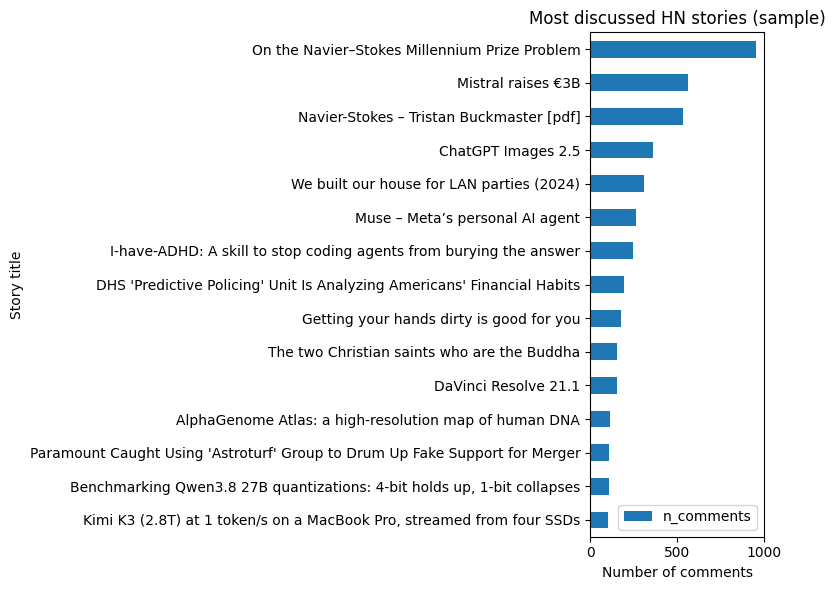

In [11]:
ax = (
    comments_per_story.sort_values('n_comments')
    .tail(15)
    .plot(kind='barh', x='title', y='n_comments', figsize=(8,6))
)
ax.set_xlabel('Number of comments')
ax.set_ylabel('Story title')
ax.set_title('Most discussed HN stories (sample)')
plt.tight_layout()
plt.show()

In [12]:
merged_df['user'].fillna('unknown').value_counts().head(10)

user
tristanj          28
20k               21
kentonv           19
dgellow           19
asdff             18
fc417fc802        17
Argonautlabs      14
redox99           14
Joel_Mckay        14
animeshchouhan    14
Name: count, dtype: int64

<small>This assignment was designed with the assistance of ChatGPT.</small>